In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Sales_Dataset_2024.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
display(df.info())

First 5 rows of the dataset:


,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit
0,12-04-2024 00:00,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634260,1908.365742
1,14-12-2024 00:00,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273
2,27-09-2024 00:00,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874
3,16-04-2024 00:00,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908
4,12-03-2024 00:00,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         2000 non-null   object 
 1   Region       1961 non-null   object 
 2   Product      1960 non-null   object 
 3   Salesperson  1960 non-null   object 
 4   Units_Sold   1960 non-null   float64
 5   Unit_Price   1960 non-null   float64
 6   Category     2000 non-null   object 
 7   Revenue      1921 non-null   float64
 8   Cost         1921 non-null   float64
 9   Profit       1921 non-null   float64
dtypes: float64(5), object(5)
memory usage: 156.4+ KB


None

In [6]:
# Convert 'Date' column to datetime objects, specifying the correct format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y %H:%M')

# Display the updated DataFrame info to confirm data type conversion
print("\nDataFrame Info after Date conversion:")
display(df.info())

# Check for missing values in all columns
print("\nMissing values per column:")
display(df.isnull().sum())


DataFrame Info after Date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2000 non-null   datetime64[ns]
 1   Region       1961 non-null   object        
 2   Product      1960 non-null   object        
 3   Salesperson  1960 non-null   object        
 4   Units_Sold   1960 non-null   float64       
 5   Unit_Price   1960 non-null   float64       
 6   Category     2000 non-null   object        
 7   Revenue      1921 non-null   float64       
 8   Cost         1921 non-null   float64       
 9   Profit       1921 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 156.4+ KB


None


Missing values per column:


,0
Date,0
Region,39
Product,40
Salesperson,40
Units_Sold,40
Unit_Price,40
Category,0
Revenue,79
Cost,79
Profit,79


In [8]:
# Fill missing values for categorical columns with the mode
for col in ['Region', 'Product', 'Salesperson']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df.loc[:, col] = df[col].fillna(mode_val) # Modified to avoid FutureWarning

# Fill missing values for numerical columns with the mean
for col in ['Units_Sold', 'Unit_Price', 'Revenue', 'Cost', 'Profit']:
    if df[col].isnull().any():
        mean_val = df[col].mean()
        df.loc[:, col] = df[col].fillna(mean_val) # Modified to avoid FutureWarning

# Verify that there are no more missing values
print("\nMissing values after imputation:")
display(df.isnull().sum())


Missing values after imputation:


,0
Date,0
Region,0
Product,0
Salesperson,0
Units_Sold,0
Unit_Price,0
Category,0
Revenue,0
Cost,0
Profit,0


In [13]:
# Define mapping for common misspellings in 'Product' column
product_corrections = {
    'Tabllet': 'Tablet',
    'Moblie': 'Mobile'
}

# Apply the corrections to the 'Product' column
df['Product'] = df['Product'].replace(product_corrections)

# Display unique values and counts for 'Product' after further standardization
print("\nUnique values and counts for 'Product' after corrections:")
display(df['Product'].value_counts())


Unique values and counts for 'Product' after corrections:


,count
Product,
Tablet,305
Smartwatch,261
Laptop,261
Monitor,240
Camera,239
Headphones,236
Mobile,229
Printer,229


In [12]:
# Identify categorical columns again (in case any were added/removed)
categorical_cols = df.select_dtypes(include='object').columns

# Standardize categorical columns by converting to title case
for col in categorical_cols:
    df.loc[:, col] = df[col].astype(str).apply(lambda x: x.title())

# Display unique values and counts for categorical columns after standardization
print("\nUnique values and counts for categorical columns after standardization:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts())


Unique values and counts for categorical columns after standardization:

Column: Region


,count
Region,
West,547
North,504
South,488
East,461



Column: Product


,count
Product,
Tablet,303
Smartwatch,261
Laptop,261
Monitor,240
Camera,239
Headphones,236
Printer,229
Mobile,227
Tabllet,2



Column: Salesperson


,count
Salesperson,
Grace,305
Hannah,256
David,256
Frank,252
Charlie,244
Eva,239
Bob,233
Alice,215



Column: Category


,count
Category,
Electronics,1013
Accessories,506
Office,481


In [11]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print("\nUnique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts())



Unique values and counts for categorical columns:

Column: Region


,count
Region,
West,547
North,504
South,486
East,461
south,2



Column: Product


,count
Product,
Tablet,303
Laptop,259
Smartwatch,259
Monitor,240
Camera,239
Headphones,234
Printer,229
Mobile,227
tabllet,2



Column: Salesperson


,count
Salesperson,
Grace,305
Hannah,256
David,256
Frank,252
Charlie,244
Eva,239
Bob,233
Alice,215



Column: Category


,count
Category,
Electronics,1013
Accessories,506
Office,481


In [10]:
# Identify numerical columns with potential negative values
numerical_cols_to_check = ['Units_Sold', 'Unit_Price', 'Revenue', 'Cost', 'Profit']

# Replace negative values with NaN
for col in numerical_cols_to_check:
    df.loc[df[col] < 0, col] = pd.NA

# Re-impute the NaN values (which now include the original negative values) with the mean of the positive values
for col in numerical_cols_to_check:
    if df[col].isnull().any():
        # Calculate mean only from non-NaN, non-negative values
        mean_val = df[col].dropna().mean()
        df.loc[:, col] = df[col].fillna(mean_val)

# Verify that there are no more negative values and display descriptive statistics again
print("\nDescriptive statistics after handling negative values and re-imputation:")
display(df.describe())


Descriptive statistics after handling negative values and re-imputation:


,Date,Units_Sold,Unit_Price,Revenue,Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024-07-01 16:25:40.800000,10.108949,1063.794569,10825.539147,8095.870818,2729.668329
min,2024-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-04-04 00:00:00,5.000000,607.750000,3766.500000,2824.961971,831.810573
50%,2024-07-01 00:00:00,10.000000,1062.118878,8787.000000,6484.702150,2087.202807
75%,2024-10-03 00:00:00,15.000000,1507.500000,16022.500000,11881.098700,3817.496895
max,2024-12-31 00:00:00,19.000000,1997.000000,37715.000000,31723.724910,14409.770720
std,NaN,5.521644,538.207029,8515.886571,6488.162525,2446.398613


In [9]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,Date,Units_Sold,Unit_Price,Revenue,Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024-07-01 16:25:40.800000,10.089286,1062.118878,10785.823529,8065.726146,2720.097383
min,2024-01-01 00:00:00,-5.000000,-100.000000,-8975.000000,-7905.695724,-1069.304276
25%,2024-04-04 00:00:00,5.000000,604.750000,3740.500000,2790.541206,821.598048
50%,2024-07-01 00:00:00,10.000000,1062.118878,8701.000000,6444.381689,2070.248239
75%,2024-10-03 00:00:00,15.000000,1507.500000,16022.500000,11881.098700,3817.496895
max,2024-12-31 00:00:00,19.000000,1997.000000,37715.000000,31723.724910,14409.770720
std,NaN,5.545274,539.943450,8548.355733,6513.182627,2452.727353


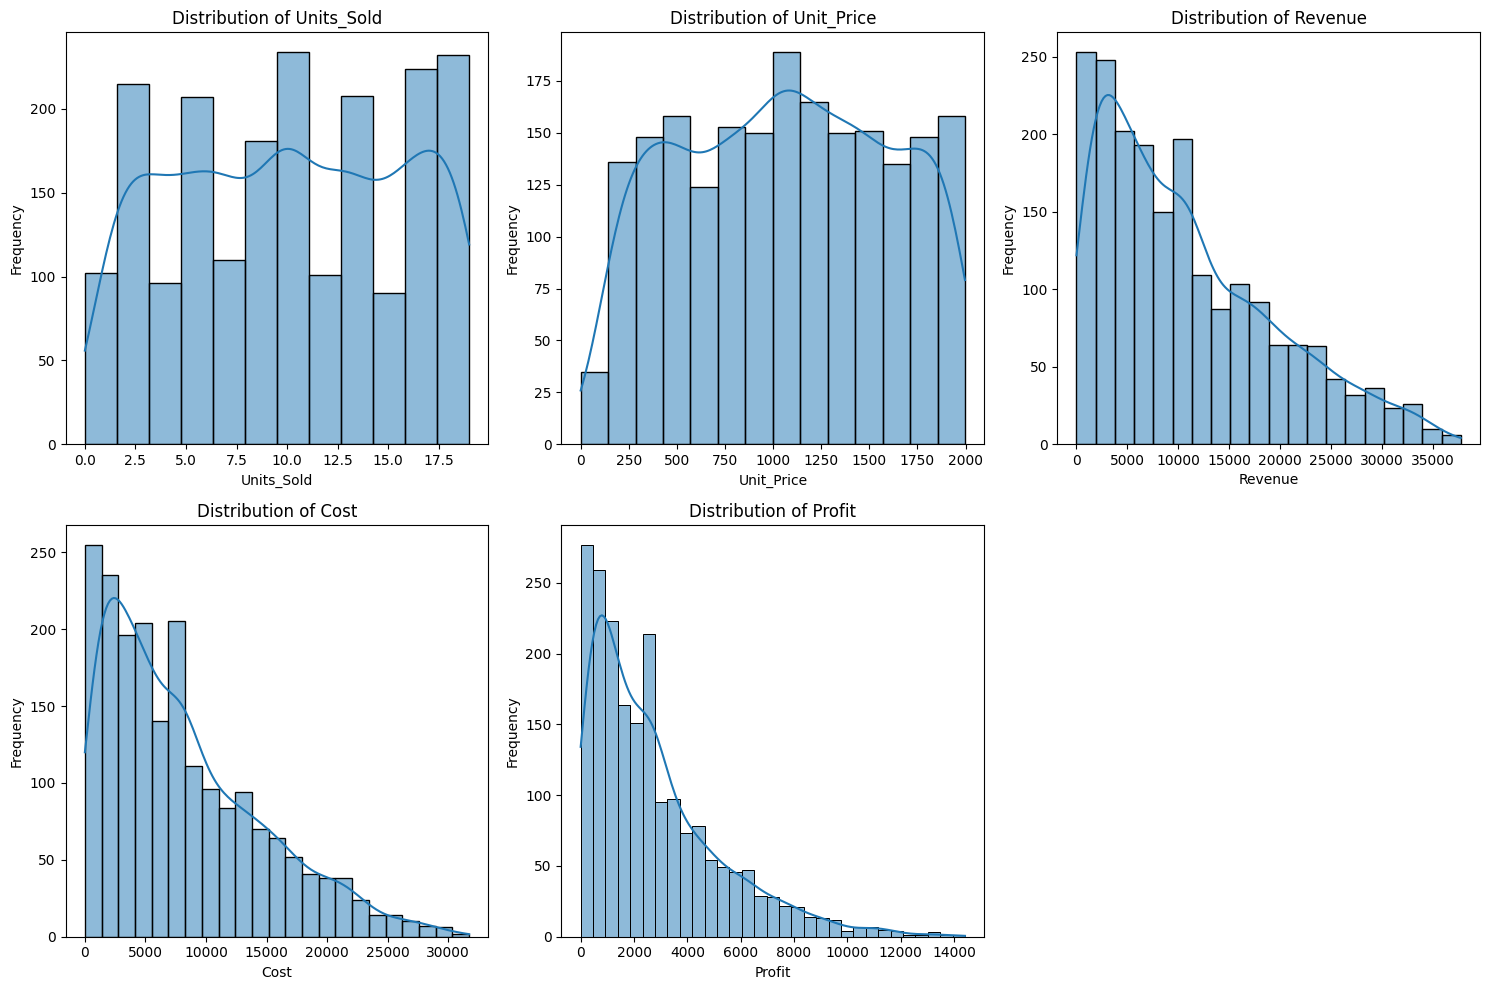

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ['Units_Sold', 'Unit_Price', 'Revenue', 'Cost', 'Profit']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

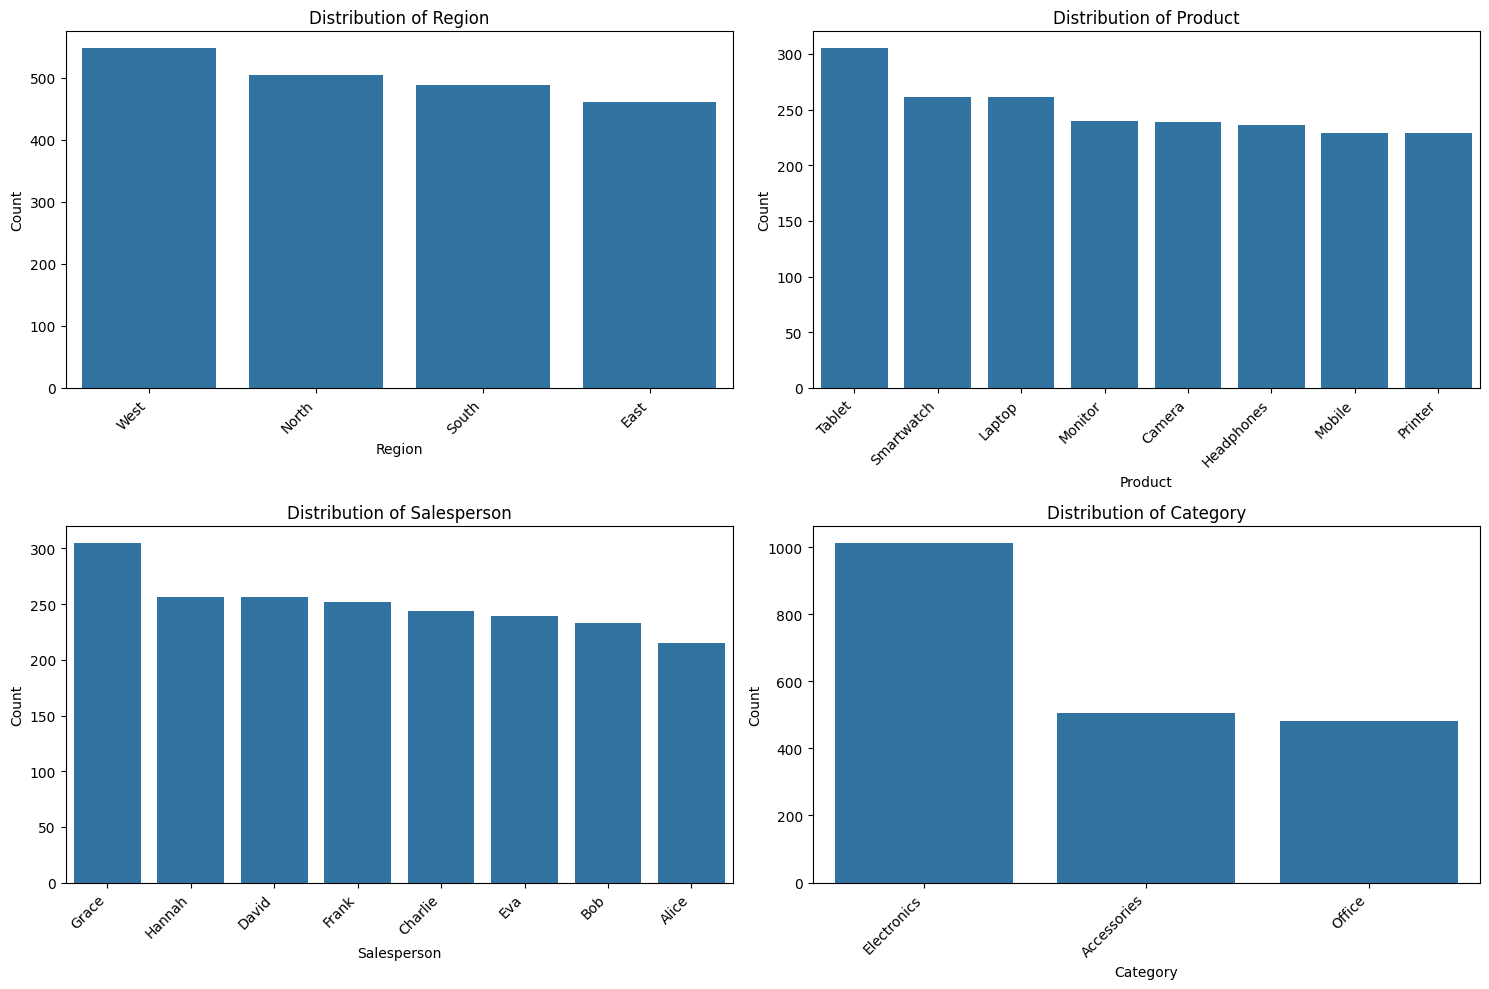

In [16]:
categorical_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i) # Adjust subplot grid based on number of categorical columns
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

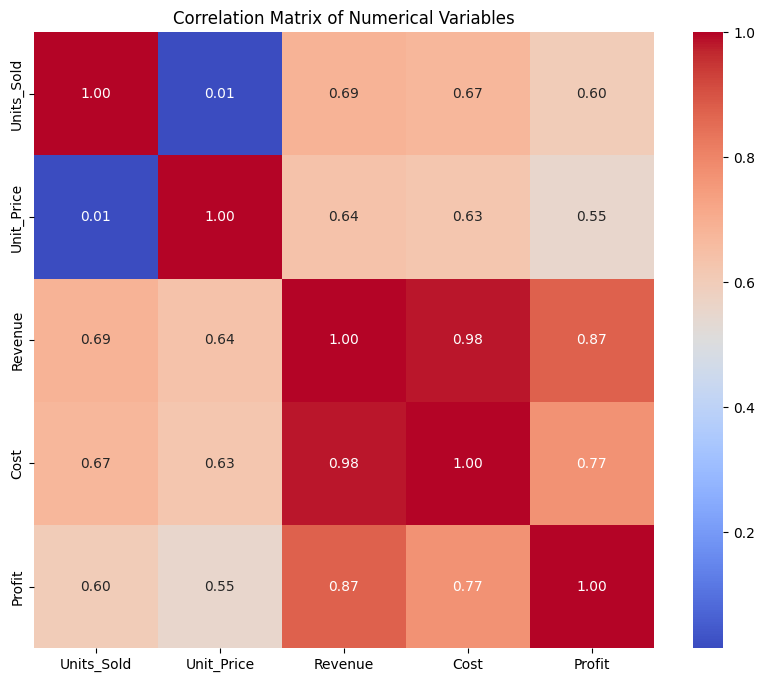

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Analyzing Revenue by Region and Product

Let's investigate how total revenue is distributed across different regions and products to identify top performers or areas that might require attention.

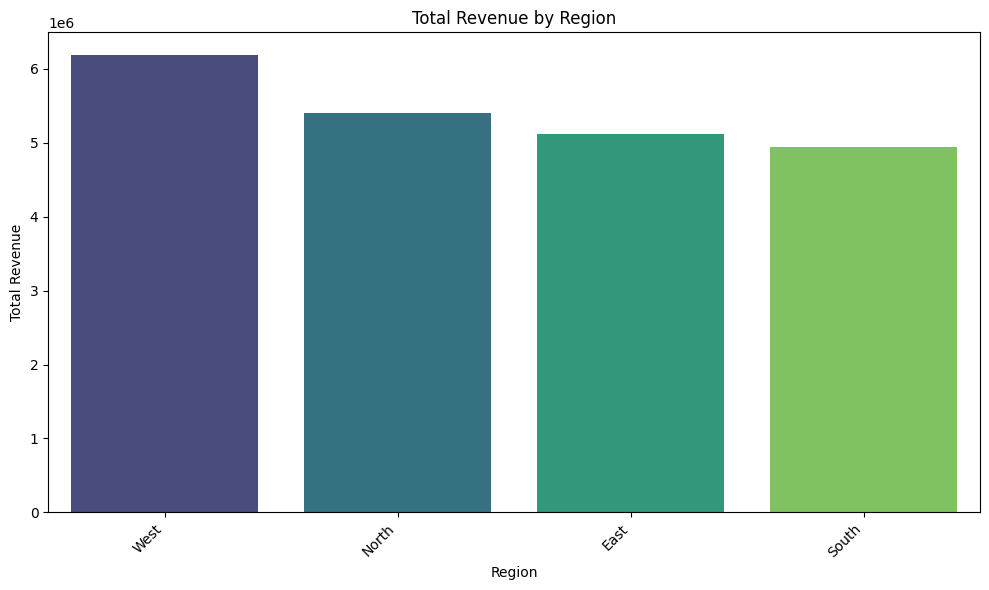

In [19]:
# Calculate total revenue by Region
revenue_by_region = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Revenue', data=revenue_by_region, palette='viridis', hue='Region', legend=False)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

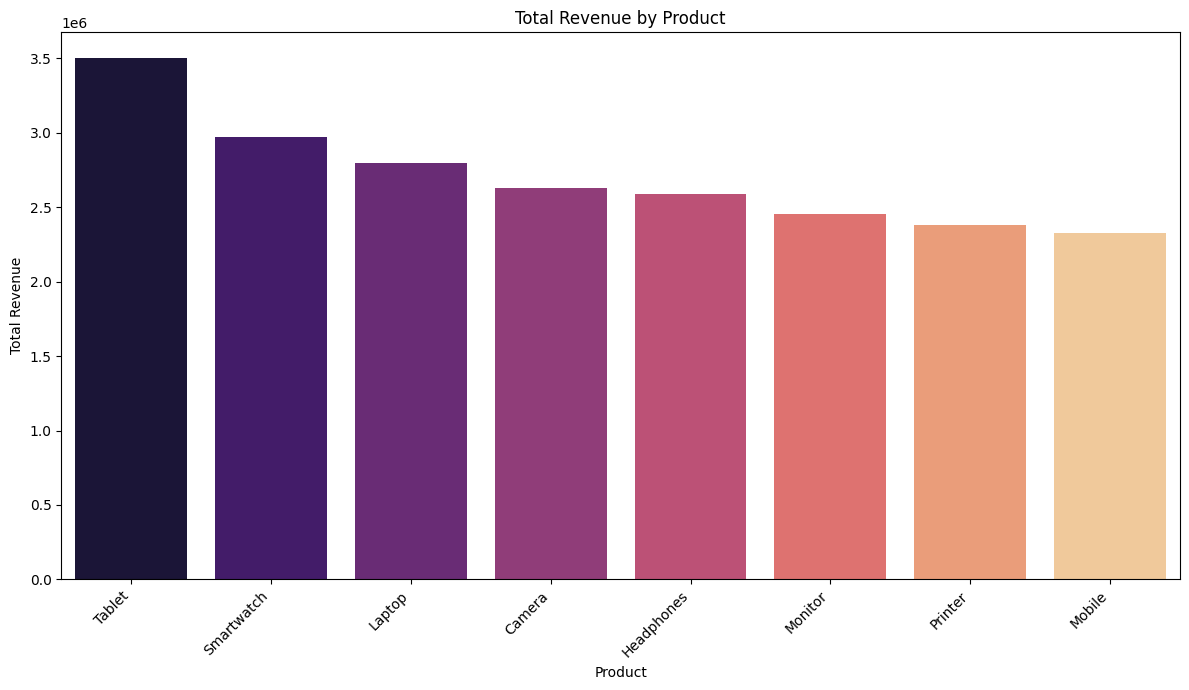

In [20]:
# Calculate total revenue by Product
revenue_by_product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='Product', y='Revenue', data=revenue_by_product, palette='magma', hue='Product', legend=False)
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df['Profit_Margin_pct'] = (df['Profit'] / df['Revenue']) * 100
df['Profit_per_Unit'] = df['Profit'] / df['Units_Sold']

print("First 5 rows of the DataFrame with new financial metrics:")
display(df.head())

First 5 rows of the DataFrame with new financial metrics:


,Date,Region,Product,Salesperson,Units_Sold,Unit_Price,Category,Revenue,Cost,Profit,Profit_Margin_pct,Profit_per_Unit
0,2024-04-12,North,Smartwatch,Hannah,15.0,1224.0,Accessories,18360.0,16451.634260,1908.365742,10.394149,127.224383
1,2024-12-14,North,Monitor,Eva,5.0,1321.0,Office,6605.0,4457.351727,2147.648273,32.515492,429.529655
2,2024-09-27,North,Mobile,Bob,11.0,912.0,Electronics,10032.0,6563.644126,3468.355874,34.572925,315.305079
3,2024-04-16,West,Monitor,Charlie,18.0,325.0,Office,5850.0,4320.807092,1529.192908,26.140050,84.955162
4,2024-03-12,West,Headphones,Eva,13.0,1042.0,Accessories,13546.0,8270.122666,5275.877334,38.947862,405.836718


In [22]:
print("\nProfit Drain Analysis (High Revenue, Potentially Low Profit Margin Categories):")
profit_drain_analysis = df.groupby('Category').agg(
    total_revenue=('Revenue', 'sum'),
    total_profit=('Profit', 'sum'),
    average_profit_margin_pct=('Profit_Margin_pct', 'mean')
).sort_values(by='total_revenue', ascending=False).reset_index()
display(profit_drain_analysis)

print("\nProfit per Unit by Category:")
profit_per_unit_by_category = df.groupby('Category')['Profit_per_Unit'].mean().sort_values(ascending=False).reset_index()
display(profit_per_unit_by_category)


Profit Drain Analysis (High Revenue, Potentially Low Profit Margin Categories):


,Category,total_revenue,total_profit,average_profit_margin_pct
0,Electronics,1.101549e+07,2.709811e+06,24.786390
1,Accessories,5.652612e+06,1.473109e+06,25.652836
2,Office,4.982979e+06,1.276417e+06,25.427676



Profit per Unit by Category:


,Category,Profit_per_Unit
0,Accessories,282.687780
1,Electronics,271.416668
2,Office,267.955536



Monthly Revenue:


,Revenue
Date,
2024-01-31,1.943849e+06
2024-02-29,1.986784e+06
2024-03-31,1.488622e+06
2024-04-30,1.954797e+06
2024-05-31,1.707457e+06



Month-over-Month Growth (%):


,Revenue
Date,
2024-01-31,NaN
2024-02-29,2.208767
2024-03-31,-25.073811
2024-04-30,31.315923
2024-05-31,-12.652973


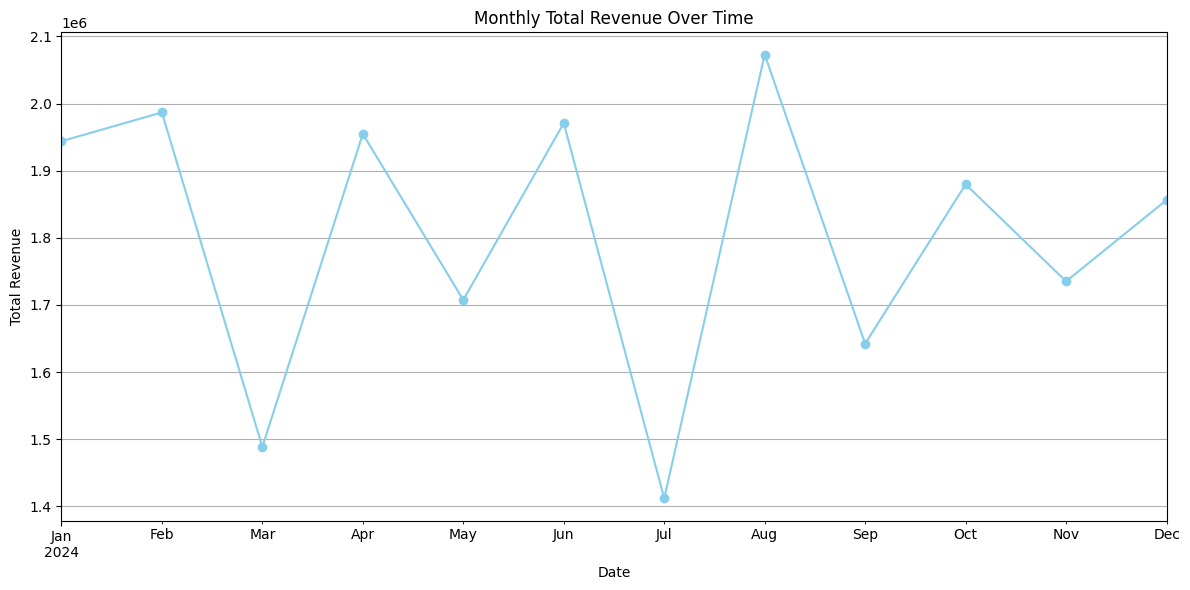

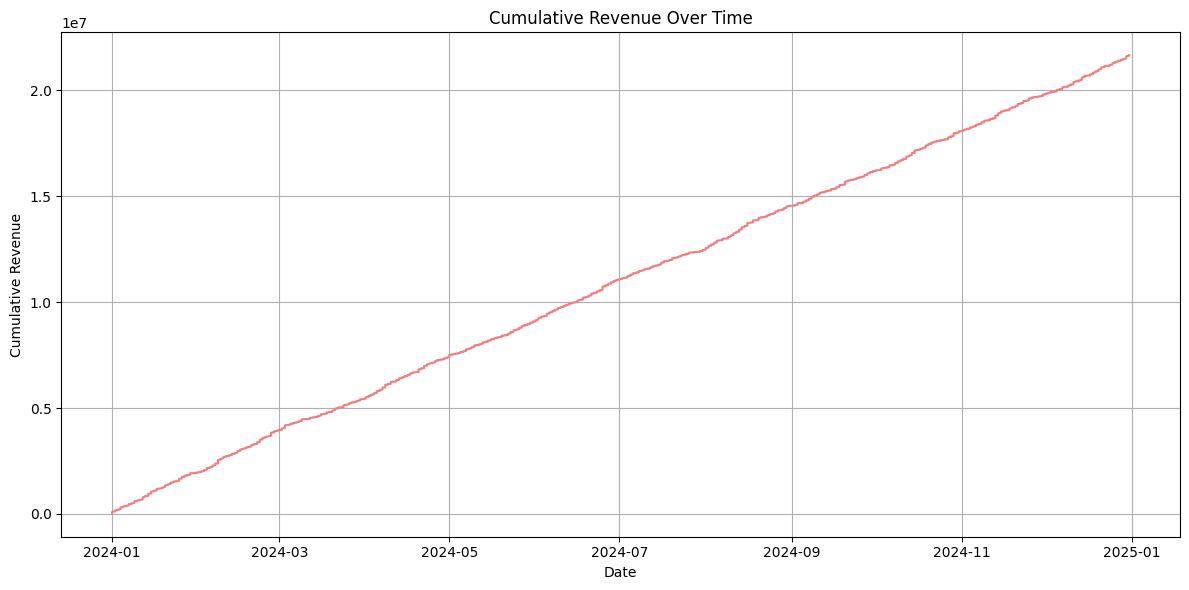

In [27]:
df_ts = df.set_index('Date').sort_index()

# Resample to monthly frequency and sum 'Revenue'
monthly_revenue = df_ts['Revenue'].resample('ME').sum()

# Calculate Month-over-Month (MoM) growth
mom_growth = monthly_revenue.pct_change() * 100

print("\nMonthly Revenue:")
display(monthly_revenue.head())
print("\nMonth-over-Month Growth (%):")
display(mom_growth.head())

# Plot Monthly Revenue to identify seasonality
plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', linestyle='-', color='skyblue')
plt.title('Monthly Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

# Sort the DataFrame by 'Date' and calculate cumulative revenue
df_ts_sorted = df.sort_values(by='Date')
df_ts_sorted['Cumulative_Revenue'] = df_ts_sorted['Revenue'].cumsum()

# Plot Cumulative Revenue
plt.figure(figsize=(12, 6))
plt.plot(df_ts_sorted['Date'], df_ts_sorted['Cumulative_Revenue'], color='lightcoral')
plt.title('Cumulative Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

## Salesperson Performance: Rainmakers Analysis

Top 5 Salespersons by Total Revenue:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct
0,Grace,3.324610e+06,879341.438403,26.010129
1,Charlie,2.871711e+06,712839.067514,24.373454
2,Frank,2.783220e+06,675798.179091,24.641505
3,David,2.695797e+06,669853.326340,25.389810
4,Hannah,2.615389e+06,669496.260288,25.053308



Top 5 Salespersons by Total Profit:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct
0,Grace,3.324610e+06,879341.438403,26.010129
1,Charlie,2.871711e+06,712839.067514,24.373454
2,Frank,2.783220e+06,675798.179091,24.641505
3,David,2.695797e+06,669853.326340,25.389810
4,Hannah,2.615389e+06,669496.260288,25.053308


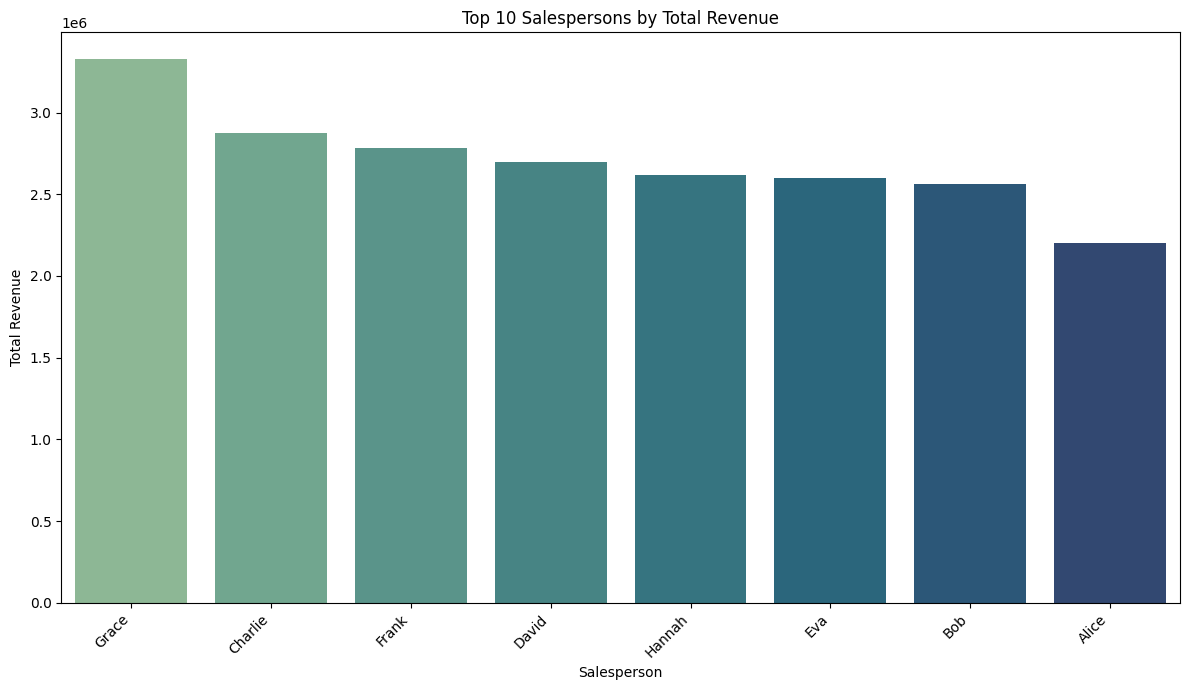

In [28]:
print("## Salesperson Performance: Rainmakers Analysis\n")

# Group by Salesperson and calculate total revenue and total profit
salesperson_performance = df.groupby('Salesperson').agg(
    total_revenue=('Revenue', 'sum'),
    total_profit=('Profit', 'sum'),
    average_profit_margin_pct=('Profit_Margin_pct', 'mean')
).sort_values(by='total_revenue', ascending=False).reset_index()

print("Top 5 Salespersons by Total Revenue:")
display(salesperson_performance.head(5))

print("\nTop 5 Salespersons by Total Profit:")
display(salesperson_performance.sort_values(by='total_profit', ascending=False).head(5))

# Plotting salesperson performance by total revenue
plt.figure(figsize=(12, 7))
sns.barplot(x='Salesperson', y='total_revenue', data=salesperson_performance.head(10), palette='crest', hue='Salesperson', legend=False)
plt.title('Top 10 Salespersons by Total Revenue')
plt.xlabel('Salesperson')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [29]:
num_salespersons = len(salesperson_performance)
top_10_percent_count = int(0.10 * num_salespersons)

print("\nTop 10% Salespersons by Total Revenue:")
display(salesperson_performance.head(top_10_percent_count))

print("\nBottom 10% Salespersons by Total Revenue:")
display(salesperson_performance.tail(top_10_percent_count))


Top 10% Salespersons by Total Revenue:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct



Bottom 10% Salespersons by Total Revenue:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct



Top 10% Salespersons by Total Revenue:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct
0,Grace,3.324610e+06,879341.438403,26.010129



Bottom 10% Salespersons by Total Revenue:


,Salesperson,total_revenue,total_profit,average_profit_margin_pct
7,Alice,2.202237e+06,545691.389279,25.226156


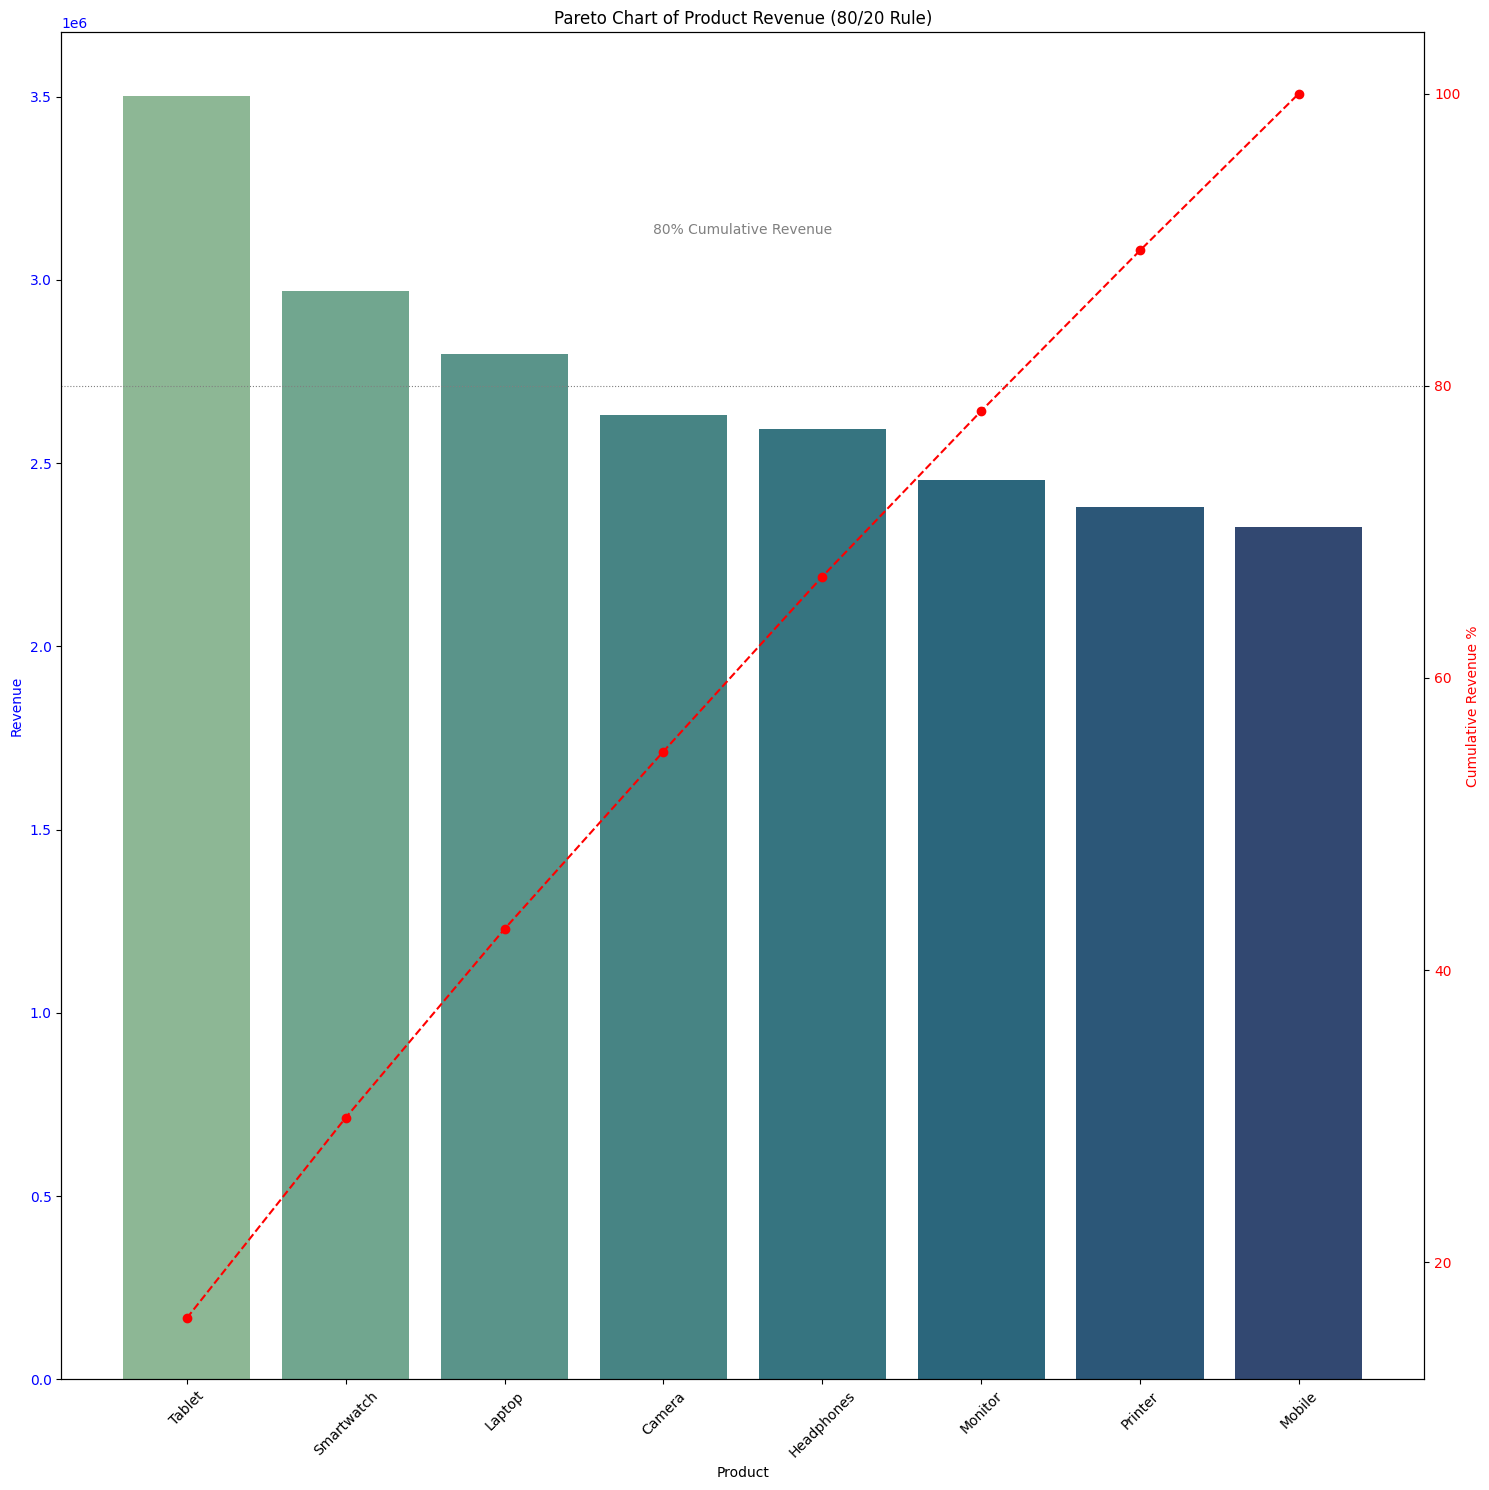

In [38]:
num_salespersons = len(salesperson_performance)
top_10_percent_count = max(1, int(0.10 * num_salespersons)) if num_salespersons > 0 else 0

print("\nTop 10% Salespersons by Total Revenue:")
display(salesperson_performance.head(top_10_percent_count))

print("\nBottom 10% Salespersons by Total Revenue:")
display(salesperson_performance.tail(top_10_percent_count))

# Calculate cumulative percentage of revenue for products
revenue_by_product['cumulative_revenue_pct'] = (revenue_by_product['Revenue'].cumsum() / revenue_by_product['Revenue'].sum()) * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(15, 15))

# Bar chart for individual product revenue
sns.barplot(x='Product', y='Revenue', data=revenue_by_product, palette='crest', ax=ax1, hue='Product', legend=False)
ax1.set_xlabel('Product')
ax1.set_ylabel('Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Pareto Chart of Product Revenue (80/20 Rule)')
ax1.tick_params(axis='x', rotation=45)

# Create a second y-axis for the cumulative percentage
ax2 = ax1.twinx()
ax2.plot(revenue_by_product['Product'], revenue_by_product['cumulative_revenue_pct'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Revenue %', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% to highlight the 80/20 rule
ax2.axhline(80, color='gray', linestyle=':', linewidth=0.8)
# Adjust text placement using ax2.transAxes for relative coordinates
ax2.text(0.5, 0.85, '80% Cumulative Revenue', color='gray', transform=ax2.transAxes, ha='center')

fig.tight_layout()
plt.show()

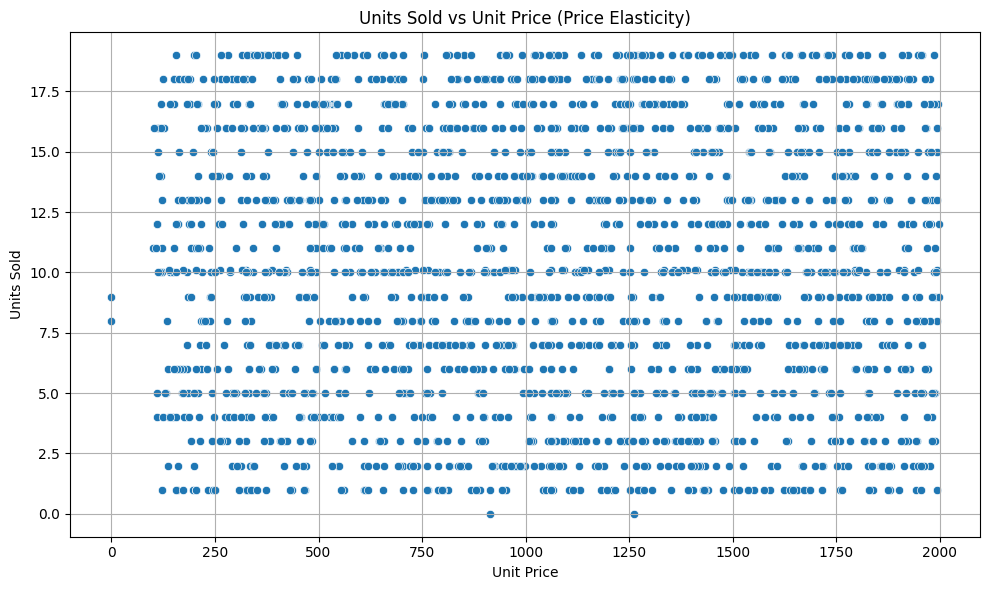


Pearson correlation between Unit_Price and Units_Sold: 0.01


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot for Units_Sold vs Unit_Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Unit_Price', y='Units_Sold', data=df)
plt.title('Units Sold vs Unit Price (Price Elasticity)')
plt.xlabel('Unit Price')
plt.ylabel('Units Sold')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate the Pearson correlation coefficient
price_elasticity_correlation = df['Unit_Price'].corr(df['Units_Sold'])
print(f"\nPearson correlation between Unit_Price and Units_Sold: {price_elasticity_correlation:.2f}")


Pearson correlation between monthly Laptop and Headphones sales: -0.19


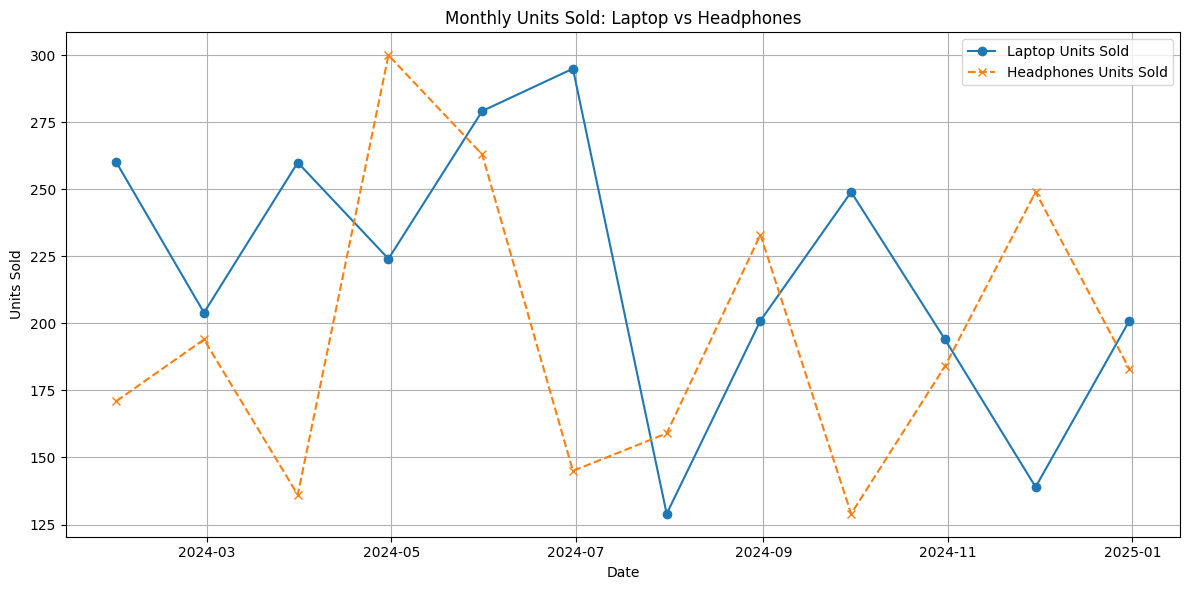

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for 'Laptop' and 'Headphones' products
cross_category_df = df[df['Product'].isin(['Laptop', 'Headphones'])]

# Set 'Date' as index and resample to monthly frequency
cross_category_monthly = cross_category_df.set_index('Date').groupby('Product')['Units_Sold'].resample('ME').sum().unstack(level=0)

# Extract sales series for Laptops and Headphones
laptop_sales = cross_category_monthly['Laptop']
headphones_sales = cross_category_monthly['Headphones']

# Calculate Pearson correlation coefficient between laptop and headphone sales
cross_category_correlation = laptop_sales.corr(headphones_sales)
print(f"\nPearson correlation between monthly Laptop and Headphones sales: {cross_category_correlation:.2f}")

# Plot monthly Units_Sold for both products
plt.figure(figsize=(12, 6))
plt.plot(laptop_sales.index, laptop_sales.values, label='Laptop Units Sold', marker='o', linestyle='-')
plt.plot(headphones_sales.index, headphones_sales.values, label='Headphones Units Sold', marker='x', linestyle='--')
plt.title('Monthly Units Sold: Laptop vs Headphones')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
import plotly.express as px

# Convert the monthly_revenue Series to a DataFrame for Plotly
monthly_revenue_df = monthly_revenue.reset_index()
monthly_revenue_df.columns = ['Date', 'Total Revenue']

# Create an interactive line chart for Monthly Total Revenue
fig = px.line(monthly_revenue_df, x='Date', y='Total Revenue', title='Interactive Monthly Total Revenue Over Time')
fig.update_layout(xaxis_title='Date', yaxis_title='Total Revenue')
fig.show()